# Telco Customer Churn Prediction
### End-to-End Machine Learning Project
**Dataset:** IBM Telco Customer Churn
**Author:** (Shrouk yasser)


## Business Understanding

### Context

A telecom company is losing customers every month.   
The company wants to **identify at-risk customers early** so the retention team can offer promotions before they leave.

---

### Business Questions

**Q1.** What are the most important customer characteristics that predict churn?  
*(demographics, services subscribed, contract type)*

**Q2.** Which contract type and payment method are most associated with high churn rates?

**Q3.** Do customers who subscribe to more add-on services churn less than those who don't?


---


# Data Understanding

In [68]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

# Load Data

In [69]:
pd.set_option('display.max_columns', None)

In [70]:
df = pd.read_csv('telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning Step

### 1 - Check Data Types

In [71]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2 - Check Missing Values

In [72]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
round((df.isna().mean()) * 100, 2)

customerID          0.00
gender              0.00
SeniorCitizen       0.00
Partner             0.00
Dependents          0.00
tenure              0.00
PhoneService        0.00
MultipleLines       0.00
InternetService     0.00
OnlineSecurity      0.00
OnlineBackup        0.00
DeviceProtection    0.00
TechSupport         0.00
StreamingTV         0.00
StreamingMovies     0.00
Contract            0.00
PaperlessBilling    0.00
PaymentMethod       0.00
MonthlyCharges      0.00
TotalCharges        0.16
Churn               0.00
dtype: float64

In [73]:
# Blank TotalCharges belong to new customers with tenure=0 → fill with 0
df['TotalCharges'].fillna(0, inplace=True)
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3 - Check Outliers

In [74]:
from sklearn.preprocessing import LabelEncoder

numeric_lst = df.select_dtypes(include='number').columns
for col in numeric_lst:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(col)
    print(f'  Outliers count : {len(outliers)}  ')
    print('_' * 30)

SeniorCitizen
  Outliers count : 1142  
______________________________
tenure
  Outliers count : 0  
______________________________
MonthlyCharges
  Outliers count : 0  
______________________________
TotalCharges
  Outliers count : 0  
______________________________


In [75]:
# Drop customerID — unique identifier with no predictive value
df.drop('customerID', axis=1, inplace=True)

# Encode target: Yes → 1  |  No → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [76]:
# Remove duplicates
df.drop_duplicates(inplace=True, ignore_index=True)
df.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

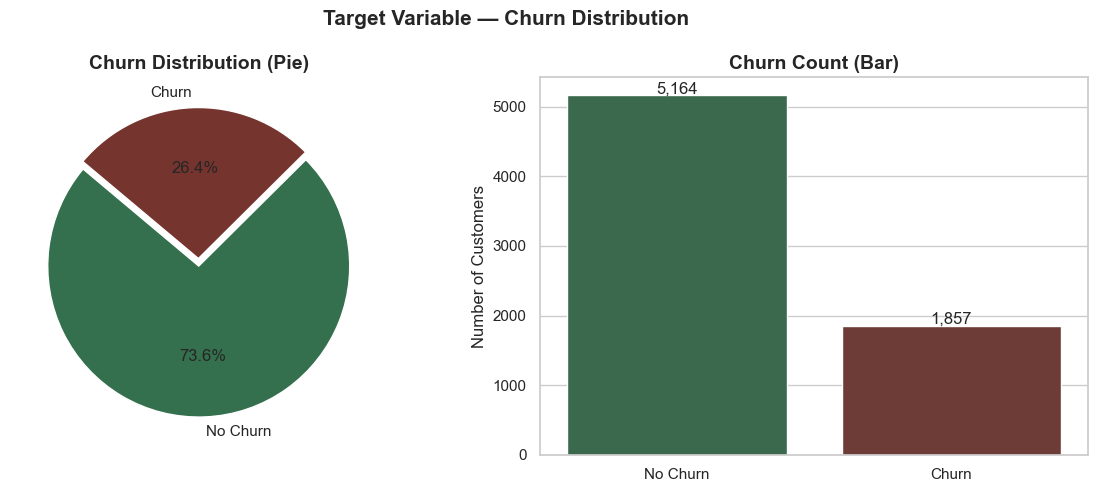

In [77]:
# ── PLOT 1: Churn Distribution 
churn_counts = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', startangle=140,
            colors=["#34704D",  "#76342E" ], explode=(0, 0.05))
axes[0].set_title('Churn Distribution (Pie)', fontsize=14, fontweight='bold')

sns.barplot(x=['No Churn', 'Churn'], y=churn_counts.values,
            palette=["#34704D",  "#76342E"], ax=axes[1])
axes[1].set_title('Churn Count (Bar)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                    ha='center', fontsize=12)

plt.suptitle('Target Variable — Churn Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

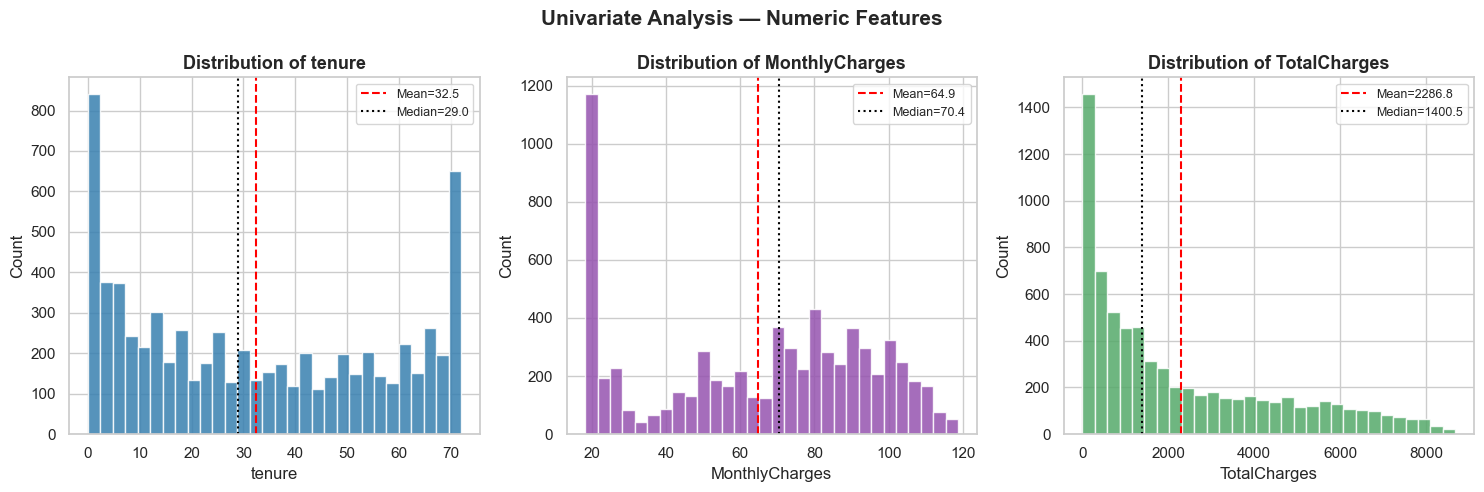

In [78]:
# ── PLOT 2: Histograms — Numeric Feature Distributions 
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = ["#3880b0", "#9553AF", "#55a96a"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',   linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='black', linestyle=':',  label=f'Median={df[col].median():.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Univariate Analysis — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



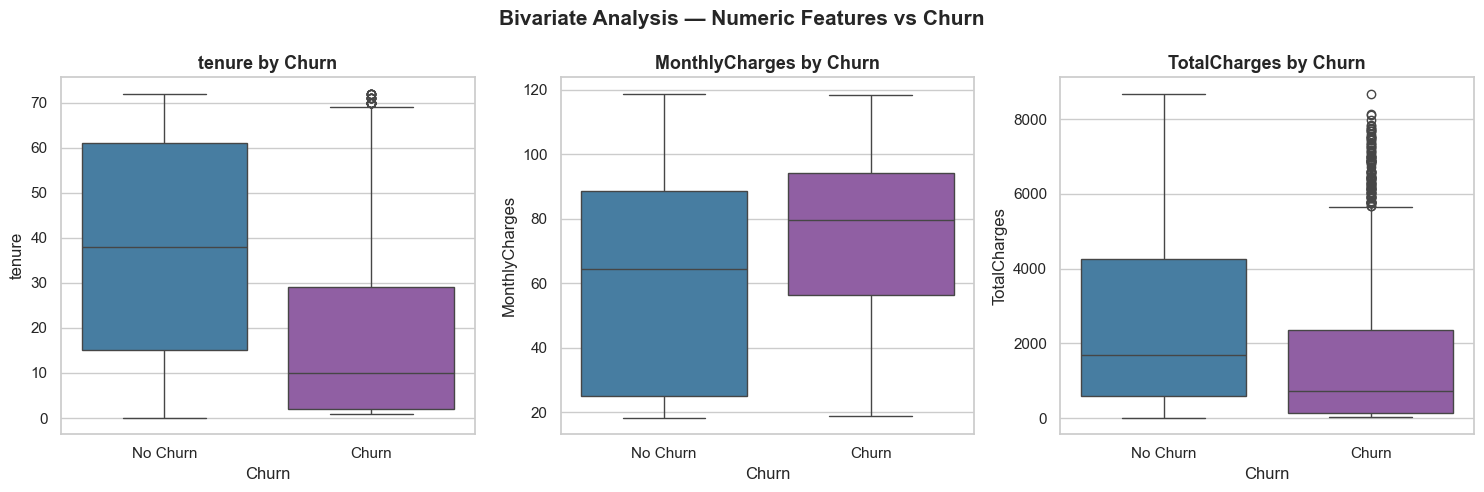

In [79]:
# PLOT 3: Box Plots — Numeric Features vs Churn 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, palette=["#3880b0" , "#9553AF"], ax=ax)
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_title(f'{col} by Churn', fontsize=13, fontweight='bold')
    mean_no  = df[df['Churn']==0][col].mean()
    mean_yes = df[df['Churn']==1][col].mean()

plt.suptitle('Bivariate Analysis — Numeric Features vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

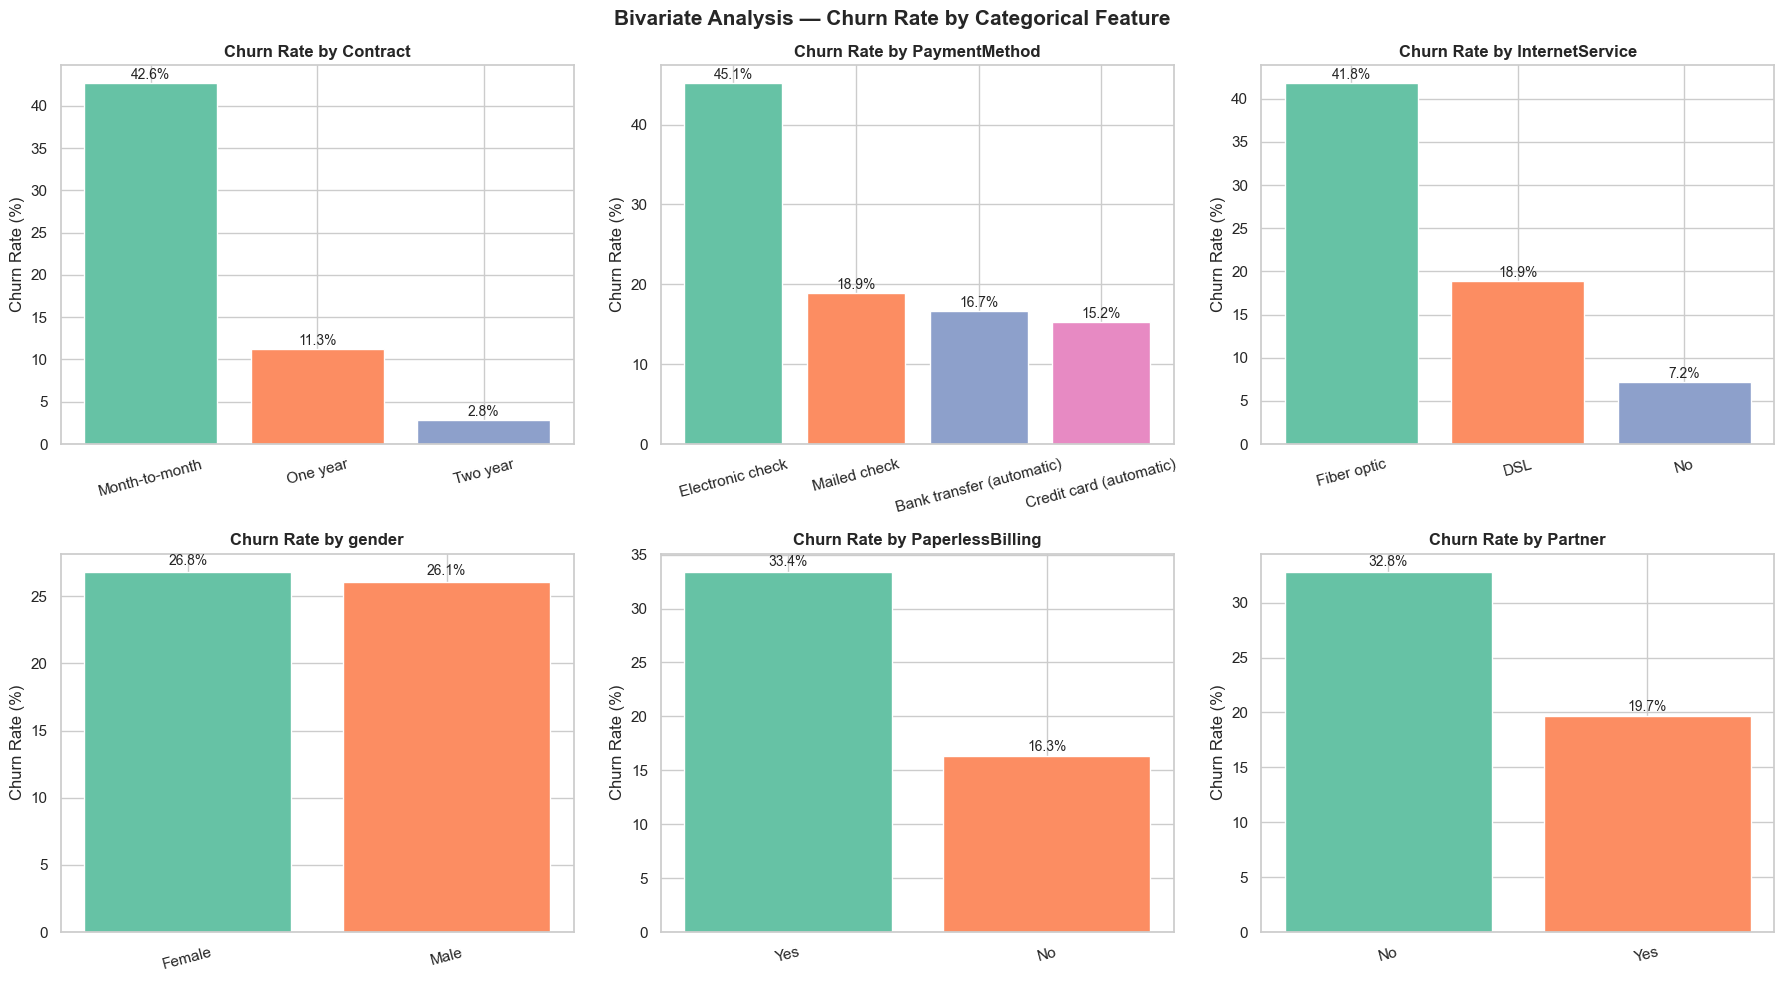

In [80]:
#  PLOT 4: Bar Charts — Categorical Features vs Churn 
cat_analysis_cols = ['Contract', 'PaymentMethod', 'InternetService',
                    'gender', 'PaperlessBilling', 'Partner']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_analysis_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                    color=sns.color_palette('Set2', len(churn_rate)))
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', fontsize=10)


plt.suptitle('Bivariate Analysis — Churn Rate by Categorical Feature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

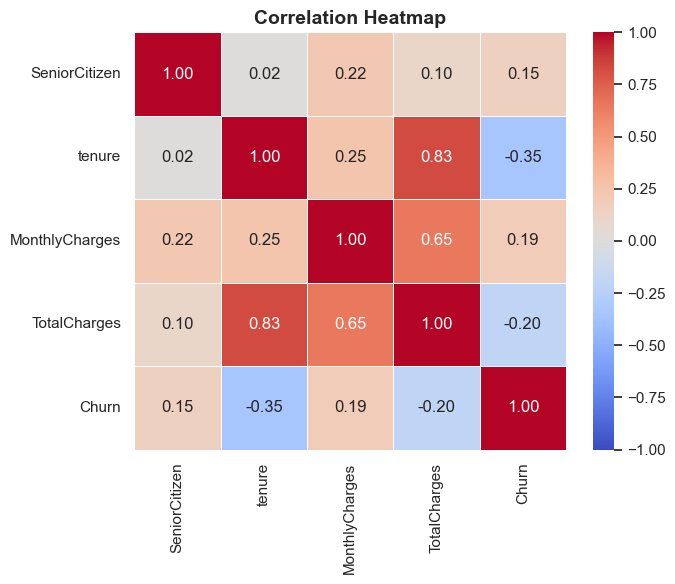

In [81]:
#  PLOT 5: Correlation Heatmap 
corr_df     = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Feature Engineering

In [82]:
# Create tenure_group based on how long the customer has been with the company
def tenure_group(x):
    if x <= 12:
        return 'New Customer'
    elif x <= 36:
        return 'Mid-term Customer'
    else:
        return 'Long-term Customer'

df['tenure'].apply(tenure_group).value_counts()

tenure
Long-term Customer    3001
New Customer          2164
Mid-term Customer     1856
Name: count, dtype: int64

In [83]:
df['tenure_group'] = df['tenure'].apply(tenure_group)
df['tenure_group'].value_counts()

tenure_group
Long-term Customer    3001
New Customer          2164
Mid-term Customer     1856
Name: count, dtype: int64

In [84]:
# Revenue efficiency metric: how much does the customer pay per month of tenure
df['ChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)
print(f"ChargesPerTenure — Mean: {df['ChargesPerTenure'].mean():.2f}  |  Std: {df['ChargesPerTenure'].std():.2f}")

ChargesPerTenure — Mean: 59.12  |  Std: 30.54


In [85]:
# Count of premium add-on services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)
df['NumServices'].value_counts().sort_index()

NumServices
0    2197
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

### Save cleaned dataframe for later use in Streamlit deployment

In [86]:
df.to_csv('cleaned_telco.csv')

# Data Preprocessing

# Data Preprocessing Steps for Machine Learning :

* 1- Split Data into Input Features and Target Column

* 2- Split Data into Train & Test

* 3- Numerical Cols : Impute Missing → Scaling

* 4- Categorical Cols : Impute Missing → Encoding

* 7- Handle Imbalance (SMOTE)

### 1 - Split Data into Input Features and Target Feature

In [87]:
x = df.drop('Churn', axis=1)
y = df['Churn']
df['Churn'].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

## Numerical Pipeline

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

si = SimpleImputer(strategy='mean')
sc = StandardScaler()

num_pipeline = Pipeline([('Imputer', si), ('Scaling', sc)])
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Imputer', ...), ('Scaling', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for

## Categorical Pipeline — One Hot Encoding

In [89]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)

ohe_pipeline = Pipeline([('OHE Pipeline', ohe)])
ohe_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('OHE Pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, d

### Ordinal Pipeline — tenure_group

In [90]:
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(categories=[['New Customer', 'Mid-term Customer', 'Long-term Customer']])
ord_pipeline = Pipeline([('Ordinal Pipeline', ord_enc)])
ord_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Ordinal Pipeline', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['New Customer', 'Mid-term Customer', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for ea

### Assign each column to the corresponding Pipeline

In [91]:
num_cols = x.select_dtypes(include='number').columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerTenure', 'NumServices'],
      dtype='object')

In [92]:
ohe_cols = x.select_dtypes(include='object').columns.drop('tenure_group')
ohe_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [93]:
from sklearn.compose import ColumnTransformer

Preprocessing = ColumnTransformer(transformers=[
    ('Numerical',   num_pipeline, num_cols),
    ('OHE',         ohe_pipeline, ohe_cols),
    ('Ordinal',     ord_pipeline, ['tenure_group'])
])
Preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...), ('OHE', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [94]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = [
    ('Logistic Regression',  LogisticRegression(random_state=42, max_iter=1000 )),
    ('Random Forest',        RandomForestClassifier(random_state=42 )),
    ('Gradient Boosting',    GradientBoostingClassifier(random_state=42)),
    ('XGBoost',              XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))
]

scoring  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
all_results = []

for name, model in models:
    model_pipeline = ImbPipeline(steps=[
        ('Preprocessing', Preprocessing),
        ('SMOTE',         SMOTE(random_state=42)),
        ('Model',         model)
    ])

    result = cross_validate(model_pipeline, x, y, scoring=scoring,
                            cv=5, return_train_score=True, n_jobs=-1)

    row = {
        'Model':          name,
        'Train Accuracy': round(result['train_accuracy'].mean() * 100, 2),
        'Test Accuracy':  round(result['test_accuracy'].mean()  * 100, 2),
        'Precision':      round(result['test_precision'].mean() * 100, 2),
        'Recall':         round(result['test_recall'].mean()    * 100, 2),
        'F1':             round(result['test_f1'].mean()        * 100, 2),
        'ROC-AUC':        round(result['test_roc_auc'].mean()   * 100, 2),
    }
    all_results.append(row)

    print(name)
    print(f'  Train Accuracy : {row["Train Accuracy"]}%')
    print(f'  Test Accuracy  : {row["Test Accuracy"]}%')
    print(f'  Precision      : {row["Precision"]}%')
    print(f'  Recall         : {row["Recall"]}%')
    print(f'  F1             : {row["F1"]}%')
    print(f'  ROC-AUC        : {row["ROC-AUC"]}%')
    print('-' * 50)

Logistic Regression
  Train Accuracy : 75.92%
  Test Accuracy  : 75.64%
  Precision      : 52.66%
  Recall         : 79.16%
  F1             : 63.22%
  ROC-AUC        : 84.68%
--------------------------------------------------
Random Forest
  Train Accuracy : 99.8%
  Test Accuracy  : 78.21%
  Precision      : 59.25%
  Recall         : 56.76%
  F1             : 57.96%
  ROC-AUC        : 82.37%
--------------------------------------------------
Gradient Boosting
  Train Accuracy : 80.81%
  Test Accuracy  : 78.78%
  Precision      : 58.8%
  Recall         : 66.45%
  F1             : 62.37%
  ROC-AUC        : 84.33%
--------------------------------------------------
XGBoost
  Train Accuracy : 93.23%
  Test Accuracy  : 78.12%
  Precision      : 59.17%
  Recall         : 56.11%
  F1             : 57.59%
  ROC-AUC        : 82.36%
--------------------------------------------------


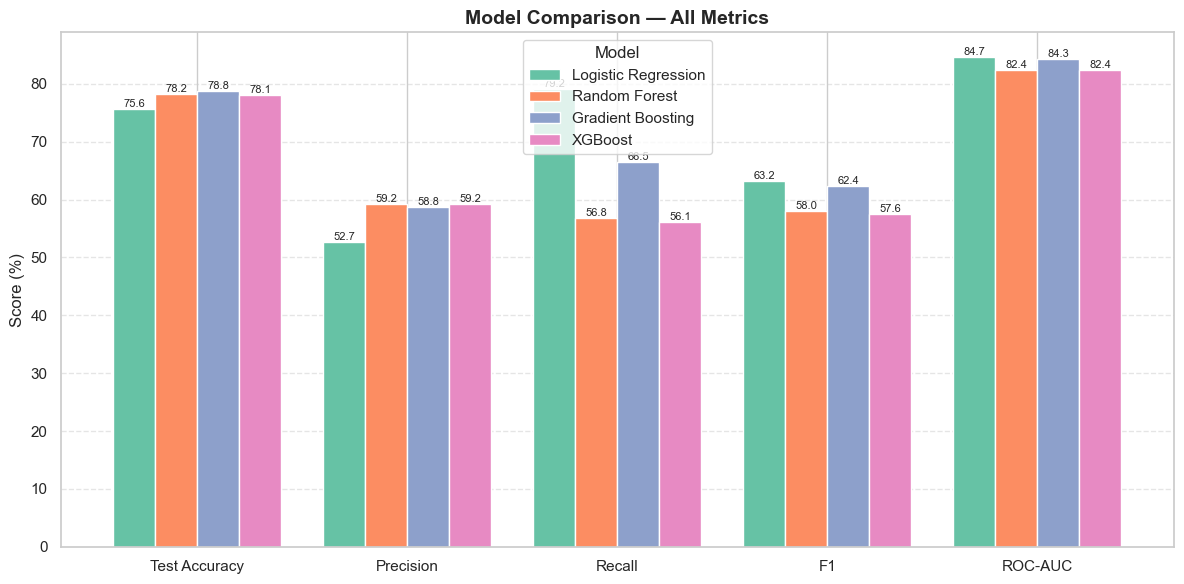

In [95]:
results_df = pd.DataFrame(all_results)

plot_df = results_df.set_index('Model')[['Test Accuracy',
                                        'Precision',
                                        'Recall',
                                        'F1',
                                        'ROC-AUC']].T

ax = plot_df.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8
)

plt.title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)

plt.tight_layout()
plt.show()

In [96]:
from sklearn.model_selection import GridSearchCV

model_pipeline = ImbPipeline(steps=[
    ('Preprocessing', Preprocessing),
    ('SMOTE', SMOTE(random_state=42)),
    ('Model', LogisticRegression(random_state=42, max_iter=1000))
])

params = {
    'Model__C': [0.01, 0.1, 1, 10],
    'Model__solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=params,
    scoring='roc_auc',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(x, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Model__C': [0.01, 0.1, ...], 'Model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t thi

In [97]:
grid_search.best_score_

0.8469693786360155

In [98]:
grid_search.best_params_

{'Model__C': 0.1, 'Model__solver': 'lbfgs'}

In [99]:
best_params = grid_search.best_params_

final_pipeline = ImbPipeline(steps=[
    ('Preprocessing', Preprocessing),
    ('SMOTE', SMOTE(random_state=42)),
    ('Model', LogisticRegression(
        C=best_params['Model__C'],
        solver=best_params['Model__solver'],
        max_iter=1000,
        random_state=42
    ))
])

final_pipeline.fit(x, y)

,steps,"[('Preprocessing', ...), ('SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int32](2,)","[0,1]"
feature_names_in_,"ndarray[object](22,)","['gender','SeniorCitizen','Partner',...,'tenure_group','ChargesPerTenure', 'NumServices']"
n_features_in_,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...), ('OHE', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [100]:
import joblib

joblib.dump(final_pipeline, 'churn_model.pkl')

['churn_model.pkl']